In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("../dataset/customer_churn_model_ready.csv")

In [3]:
df.head()

,gender,senior_citizen,partner,dependents,tenure_months,phone_service,multiple_lines,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn
0,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
1,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1
2,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,1
3,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,1
4,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,1


In [4]:
df.shape

(7043, 20)

In [5]:
df.columns

Index(['gender', 'senior_citizen', 'partner', 'dependents', 'tenure_months',
       'phone_service', 'multiple_lines', 'internet_service',
       'online_security', 'online_backup', 'device_protection', 'tech_support',
       'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing',
       'payment_method', 'monthly_charges', 'total_charges', 'churn'],
      dtype='object')

In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             7043 non-null   object 
 1   senior_citizen     7043 non-null   object 
 2   partner            7043 non-null   object 
 3   dependents         7043 non-null   object 
 4   tenure_months      7043 non-null   int64  
 5   phone_service      7043 non-null   object 
 6   multiple_lines     7043 non-null   object 
 7   internet_service   7043 non-null   object 
 8   online_security    7043 non-null   object 
 9   online_backup      7043 non-null   object 
 10  device_protection  7043 non-null   object 
 11  tech_support       7043 non-null   object 
 12  streaming_tv       7043 non-null   object 
 13  streaming_movies   7043 non-null   object 
 14  contract           7043 non-null   object 
 15  paperless_billing  7043 non-null   object 
 16  payment_method     7043 

In [7]:
df["churn"].value_counts()

churn
0    5174
1    1869
Name: count, dtype: int64

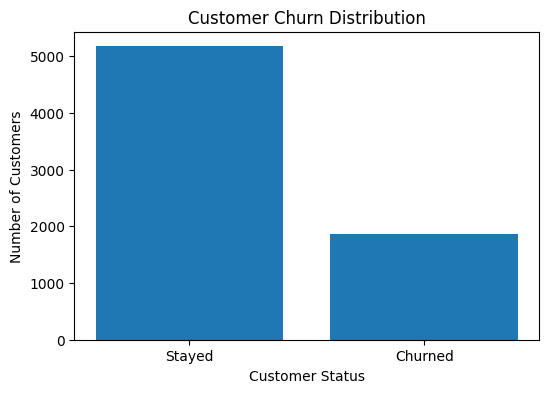

In [8]:
import matplotlib.pyplot as plt

churn_counts = df["churn"].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(
    ["Stayed", "Churned"],
    [churn_counts[0], churn_counts[1]]
)
plt.title("Customer Churn Distribution")
plt.xlabel("Customer Status")
plt.ylabel("Number of Customers")
plt.show()

In [9]:
contract_churn = pd.crosstab(
    df["contract"],
    df["churn"]
)

contract_churn

churn,0,1
contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


In [10]:
contract_churn_rate = (
    df.groupby("contract")["churn"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

contract_churn_rate

contract
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
Name: churn, dtype: float64

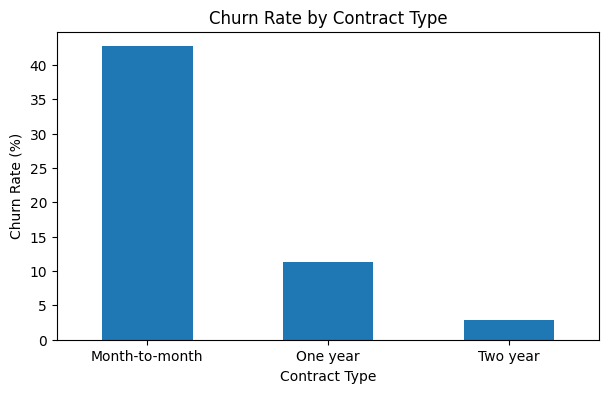

In [11]:
plt.figure(figsize=(7, 4))

contract_churn_rate.plot(kind="bar")

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.show()

In [12]:
tenure_bins = [0, 6, 12, 24, 48, 72]
tenure_labels = [
    "0-6 months",
    "7-12 months",
    "13-24 months",
    "25-48 months",
    "49-72 months"
]

df["tenure_group"] = pd.cut(
    df["tenure_months"],
    bins=tenure_bins,
    labels=tenure_labels,
    include_lowest=True
)

In [13]:
tenure_churn_rate = (
    df.groupby("tenure_group", observed=True)["churn"]
    .mean()
    .mul(100)
)

tenure_churn_rate

tenure_group
0-6 months      52.937205
7-12 months     35.886525
13-24 months    28.710938
25-48 months    20.388959
49-72 months     9.513176
Name: churn, dtype: float64

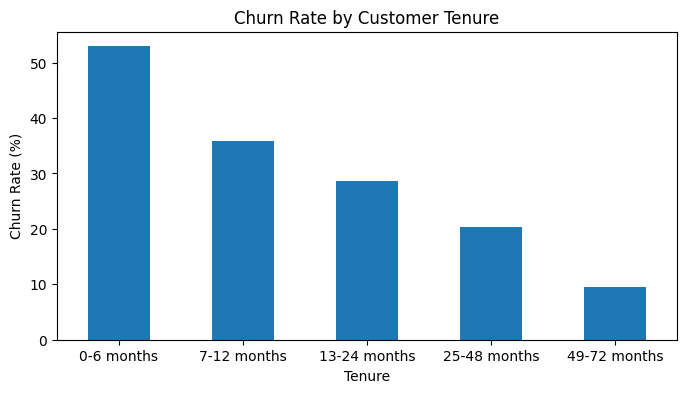

In [16]:
plt.figure(figsize=(8, 4))

tenure_churn_rate.plot(kind="bar")

plt.title("Churn Rate by Customer Tenure")
plt.xlabel("Tenure")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.show()

In [20]:
charge_bins = [0, 30, 60, 90, 120, float("inf")]

charge_labels = [
    "0-30",
    "31-60",
    "61-90",
    "91-120",
    "120+"
]

df["monthly_charge_group"] = pd.cut(
    df["monthly_charges"],
    bins=charge_bins,
    labels=charge_labels,
    include_lowest=True
)

In [21]:
charge_churn_rate = (
    df.groupby("monthly_charge_group", observed=True)["churn"]
    .mean()
    .mul(100)
)

charge_churn_rate

monthly_charge_group
0-30       9.800363
31-60     25.928854
61-90     33.906119
91-120    32.777458
Name: churn, dtype: float64

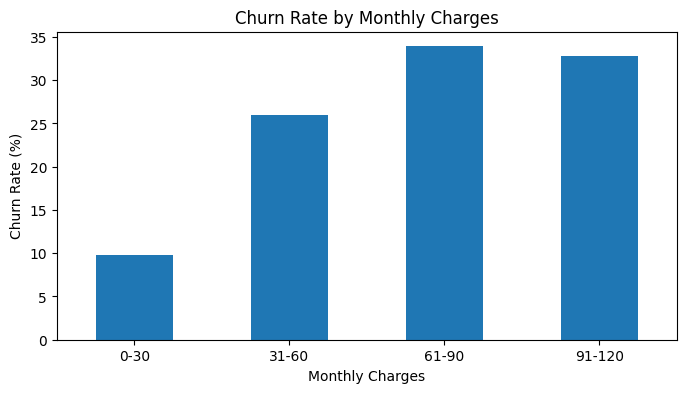

In [22]:
plt.figure(figsize=(8, 4))

charge_churn_rate.plot(kind="bar")

plt.title("Churn Rate by Monthly Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.show()

In [23]:
internet_churn_rate = (
    df.groupby("internet_service")["churn"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

internet_churn_rate

internet_service
Fiber optic    41.892765
DSL            18.959108
No              7.404980
Name: churn, dtype: float64

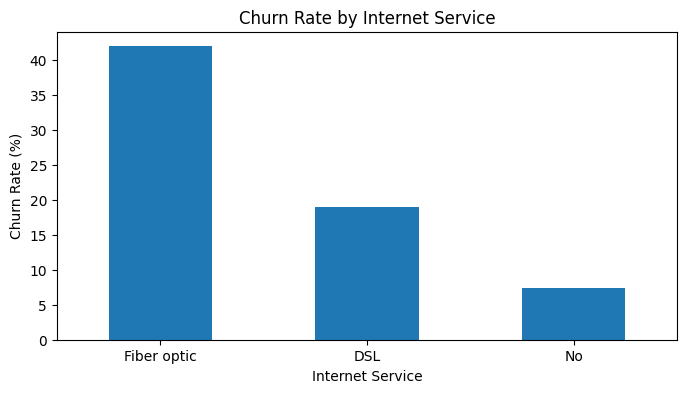

In [24]:
plt.figure(figsize=(8, 4))

internet_churn_rate.plot(kind="bar")

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.show()